# RetailPulse - Day 11: Feature Importance Analysis and Model Tuning with Optuna
**Week:** 2 | **Day:** 11

---
## Objectives
1. Install and understand Optuna (hyperparameter optimization framework)
2. **Deep feature importance analysis** for the churn model:
   - XGBoost built-in importance (recap from Day 9)
   - **Permutation importance** (model-agnostic, more reliable)
   - Compare the two methods
3. **Optuna tuning for XGBoost (Churn model)** - maximize AUC-ROC
4. **Optuna tuning for LSTM (Forecasting model)** - minimize MAPE
5. Compare tuned vs baseline models for BOTH tasks
6. Visualize the Optuna optimization process (history, parameter importance)
7. Save the best models and best hyperparameters

---
## What is Optuna and Why Use It?

Up to now we picked hyperparameters (like XGBoost's `max_depth`, `learning_rate`,
or LSTM's `hidden_size`) by hand, using reasonable defaults. **Optuna** is a
hyperparameter optimization library that automatically searches for the BEST
combination of hyperparameters by:

1. Defining a **search space** (ranges of values to try for each hyperparameter)
2. Defining an **objective function** that trains a model with given hyperparameters
   and returns a score (e.g. AUC-ROC, or MAPE)
3. Running many **trials**, where Optuna intelligently picks which hyperparameters
   to try next based on results from PREVIOUS trials (this is called **TPE -
   Tree-structured Parzen Estimator**, much smarter than random or grid search)
4. Returning the trial with the BEST score

**Why not just Grid Search?**
- Grid search tries EVERY combination - if you have 5 hyperparameters with 5
  values each, that's 5^5 = 3,125 combinations. Very slow.
- Optuna uses past results to intelligently skip combinations unlikely to be good,
  finding strong hyperparameters in far fewer trials (e.g. 50 trials instead of 3,125).

---
## Why Two Types of Feature Importance?

**XGBoost built-in importance** (Day 9) measures how often/usefully a feature was
used to SPLIT trees during training. It can be biased towards high-cardinality
or continuous features.

**Permutation importance** is model-agnostic and more trustworthy: it shuffles
(randomizes) ONE feature at a time in the TEST set and measures how much the
model's performance DROPS. If shuffling a feature hurts performance a lot, that
feature is genuinely important. If shuffling barely changes performance, the
feature wasn't doing much real work - even if XGBoost's internal importance
score said otherwise.


In [3]:
# ============================================================
# CELL 1: INSTALL AND IMPORT LIBRARIES
# ============================================================
# If Optuna is not installed, run in terminal:
#   pip install optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

import optuna
from optuna.visualization.matplotlib import (plot_optimization_history,
                                               plot_param_importances)

import pickle
import json
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../plots', exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100

optuna.logging.set_verbosity(optuna.logging.WARNING)  # keep notebook output clean

print('Libraries imported successfully')
print(f'  Optuna version  : {optuna.__version__}')
print(f'  XGBoost version : {xgb.__version__}')


Libraries imported successfully
  Optuna version  : 4.9.0
  XGBoost version : 3.2.0


## PART A: Deep Feature Importance Analysis (Churn Model)

We reload the churn features and model from Day 9 and dig deeper into feature
importance using **permutation importance**, comparing it against XGBoost's
built-in importance.


In [4]:
# ============================================================
# CELL 2: LOAD CHURN DATA AND MODEL FROM DAY 9
# ============================================================

features = pd.read_csv('../data/churn_features.csv')

with open('../models/churn_xgboost.pkl', 'rb') as f:
    churn_model_baseline = pickle.load(f)

with open('../models/churn_metrics.json', 'r') as f:
    churn_metrics_baseline = json.load(f)

feature_cols = churn_metrics_baseline['feature_columns']

X = features[feature_cols]
y = features['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Loaded churn data: {len(features):,} customers, {len(feature_cols)} features')
print(f'Baseline AUC-ROC (from Day 9): {churn_metrics_baseline["auc_roc"]:.4f}')
print(f'Baseline Precision@Top20%    : {churn_metrics_baseline["precision_at_top20"]:.4f}')


Loaded churn data: 5,281 customers, 10 features
Baseline AUC-ROC (from Day 9): 0.8143
Baseline Precision@Top20%    : 0.8863


In [5]:
# ============================================================
# CELL 3: XGBOOST BUILT-IN IMPORTANCE (RECAP)
# ============================================================

builtin_importance = pd.Series(
    churn_model_baseline.feature_importances_, index=feature_cols
).sort_values(ascending=False)

print('XGBoost Built-in Importance (Gain-based):')
print(builtin_importance.round(4))


XGBoost Built-in Importance (Gain-based):
AvgDaysBetweenOrders   0.2498
RecencyRatio           0.1498
Recency                0.1389
Frequency              0.0889
TotalQuantity          0.0739
Monetary               0.0699
UniqueProducts         0.0683
Tenure                 0.0568
AvgOrderValue          0.0526
AvgBasketSize          0.0511
dtype: float32


In [6]:
# ============================================================
# CELL 4: PERMUTATION IMPORTANCE
# ============================================================
# Permutation importance measures: how much does AUC-ROC DROP when
# we shuffle (randomize) one feature at a time in the test set?
# We repeat the shuffle 30 times per feature to get a stable average
# and a confidence interval (std).

perm_result = permutation_importance(
    churn_model_baseline, X_test, y_test,
    n_repeats=30, random_state=42,
    scoring='roc_auc'
)

perm_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

print('Permutation Importance (drop in AUC-ROC when feature is shuffled):')
print(perm_importance.round(4))


Permutation Importance (drop in AUC-ROC when feature is shuffled):
                Feature  Importance_Mean  Importance_Std
0  AvgDaysBetweenOrders           0.0559          0.0069
1               Recency           0.0505          0.0068
2          RecencyRatio           0.0209          0.0035
3        UniqueProducts           0.0105          0.0036
4         TotalQuantity           0.0086          0.0032
5              Monetary           0.0042          0.0024
6         AvgOrderValue           0.0039          0.0023
7                Tenure           0.0029          0.0021
8             Frequency           0.0013          0.0011
9         AvgBasketSize           0.0012          0.0019


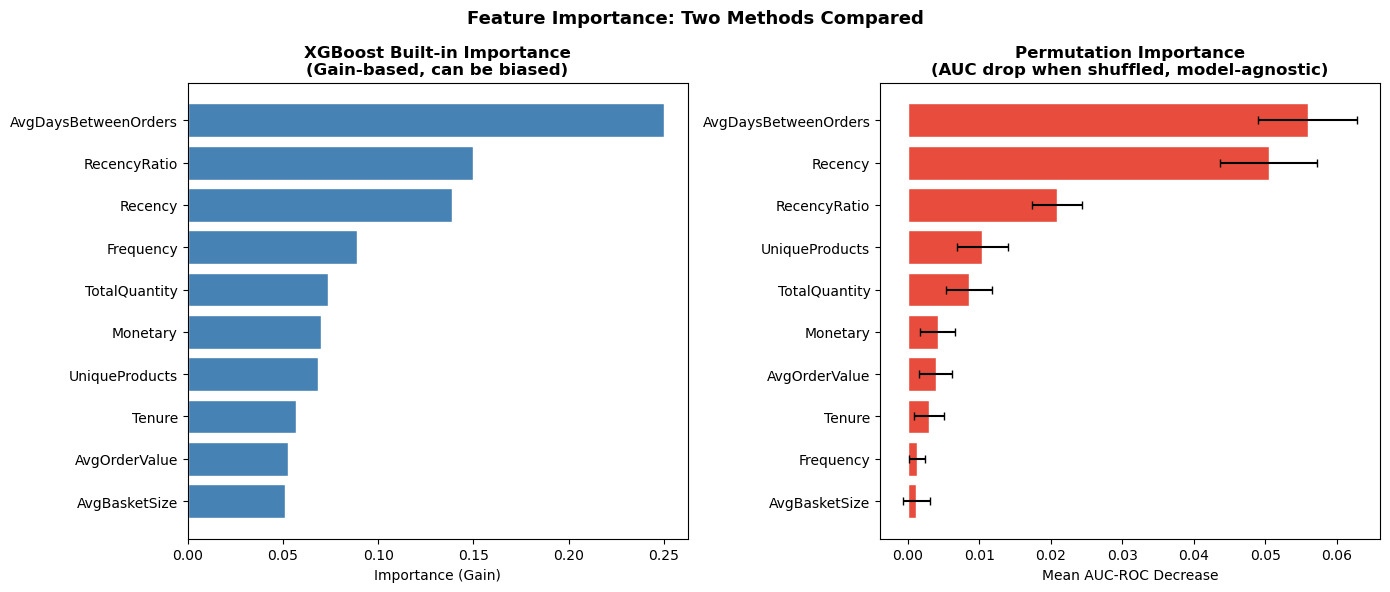

Saved: ../plots/Day11_importance_comparison.png

Ranking comparison (1 = most important):
                      Builtin_Rank  Permutation_Rank
AvgDaysBetweenOrders        1.0000            1.0000
RecencyRatio                2.0000            3.0000
Recency                     3.0000            2.0000
Frequency                   4.0000            9.0000
TotalQuantity               5.0000            5.0000
Monetary                    6.0000            6.0000
UniqueProducts              7.0000            4.0000
Tenure                      8.0000            8.0000
AvgOrderValue               9.0000            7.0000
AvgBasketSize              10.0000           10.0000

Spearman rank correlation between the two methods: 0.758
(Closer to 1.0 = the two methods agree on which features matter most)


In [7]:
# ============================================================
# CELL 5: COMPARE BUILT-IN VS PERMUTATION IMPORTANCE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Built-in importance
builtin_sorted = builtin_importance.sort_values(ascending=True)
axes[0].barh(builtin_sorted.index, builtin_sorted.values,
             color='steelblue', edgecolor='white')
axes[0].set_title('XGBoost Built-in Importance\n(Gain-based, can be biased)',
                   fontweight='bold')
axes[0].set_xlabel('Importance (Gain)')

# Permutation importance
perm_sorted = perm_importance.sort_values('Importance_Mean', ascending=True)
axes[1].barh(perm_sorted['Feature'], perm_sorted['Importance_Mean'],
             xerr=perm_sorted['Importance_Std'],
             color='#e74c3c', edgecolor='white', capsize=3)
axes[1].set_title('Permutation Importance\n(AUC drop when shuffled, model-agnostic)',
                   fontweight='bold')
axes[1].set_xlabel('Mean AUC-ROC Decrease')

plt.suptitle('Feature Importance: Two Methods Compared', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day11_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day11_importance_comparison.png')
print()

# Check if rankings agree
builtin_rank = builtin_importance.rank(ascending=False)
perm_rank = perm_importance.set_index('Feature')['Importance_Mean'].rank(ascending=False)
rank_compare = pd.DataFrame({
    'Builtin_Rank': builtin_rank,
    'Permutation_Rank': perm_rank
}).sort_values('Builtin_Rank')
print('Ranking comparison (1 = most important):')
print(rank_compare)
print()
corr = rank_compare['Builtin_Rank'].corr(rank_compare['Permutation_Rank'], method='spearman')
print(f'Spearman rank correlation between the two methods: {corr:.3f}')
print('(Closer to 1.0 = the two methods agree on which features matter most)')


## PART B: Optuna Hyperparameter Tuning for the Churn Model (XGBoost)

**Search space we will tune:**

| Hyperparameter | Range | Effect |
|-----------------|-------|--------|
| `n_estimators` | 50-500 | Number of trees |
| `max_depth` | 2-8 | Tree depth (overfitting risk if too high) |
| `learning_rate` | 0.001-0.3 (log scale) | Step size shrinkage |
| `subsample` | 0.5-1.0 | Fraction of rows sampled per tree |
| `colsample_bytree` | 0.5-1.0 | Fraction of features sampled per tree |
| `min_child_weight` | 1-10 | Minimum samples needed in a leaf |
| `gamma` | 0-5 | Minimum loss reduction needed to split further |

**Objective:** maximize AUC-ROC on a validation split (carved out of the training data,
NOT the final test set - we keep the test set untouched until the very end for an
unbiased final evaluation).


In [8]:
# ============================================================
# CELL 6: CREATE A SEPARATE VALIDATION SET FOR TUNING
# ============================================================
# IMPORTANT: We split X_train further into (tune_train, tune_val).
# Optuna will only ever see tune_train/tune_val during the search.
# The original X_test stays completely untouched until final evaluation,
# giving us an honest, unbiased estimate of real-world performance.

X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f'Tuning train set : {len(X_tune_train):,}')
print(f'Tuning val set   : {len(X_tune_val):,}')
print(f'Final test set   : {len(X_test):,}  (untouched until the end)')


Tuning train set : 3,379
Tuning val set   : 845
Final test set   : 1,057  (untouched until the end)


In [9]:
# ============================================================
# CELL 7: DEFINE THE OPTUNA OBJECTIVE FUNCTION (CHURN/XGBOOST)
# ============================================================

scale_pos_weight = (y_tune_train == 0).sum() / (y_tune_train == 1).sum()

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_int('max_depth', 2, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric':      'auc',
        'random_state':     42,
        'use_label_encoder': False,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_tune_train, y_tune_train, verbose=False)

    val_pred_proba = model.predict_proba(X_tune_val)[:, 1]
    auc = roc_auc_score(y_tune_val, val_pred_proba)

    return auc

print('Objective function defined.')
print('Goal: MAXIMIZE AUC-ROC on the validation set')


Objective function defined.
Goal: MAXIMIZE AUC-ROC on the validation set


In [10]:
# ============================================================
# CELL 8: RUN OPTUNA STUDY FOR XGBOOST (CHURN MODEL)
# ============================================================

N_TRIALS_XGB = 50

study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

print(f'Running {N_TRIALS_XGB} Optuna trials for XGBoost (Churn model) ...')
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS_XGB, show_progress_bar=True)

print()
print('Optuna search complete!')
print(f'  Best validation AUC-ROC : {study_xgb.best_value:.4f}')
print(f'  Best trial number       : {study_xgb.best_trial.number}')
print()
print('Best hyperparameters found:')
for key, val in study_xgb.best_params.items():
    print(f'  {key}: {val}')


Running 50 Optuna trials for XGBoost (Churn model) ...


  0%|          | 0/50 [00:00<?, ?it/s]


Optuna search complete!
  Best validation AUC-ROC : 0.8018
  Best trial number       : 37

Best hyperparameters found:
  n_estimators: 364
  max_depth: 3
  learning_rate: 0.038609314129159016
  subsample: 0.5327822249040789
  colsample_bytree: 0.7039147285447093
  min_child_weight: 1
  gamma: 2.6405301479192484


<Figure size 1000x500 with 0 Axes>

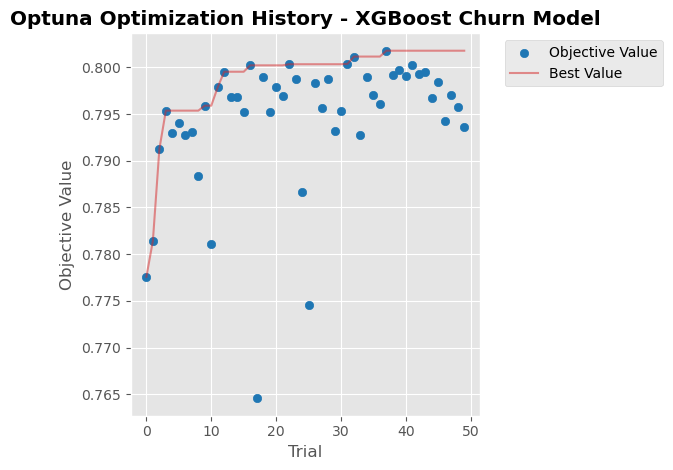

Saved: ../plots/Day11_optuna_history_xgb.png

Each blue dot = one trial. The red line shows the BEST score found so far.
A rising/flattening line means Optuna is converging on good hyperparameters.


In [11]:
# ============================================================
# CELL 9: VISUALIZE OPTUNA OPTIMIZATION HISTORY (XGBOOST)
# ============================================================

fig = plt.figure(figsize=(10, 5))
ax = plot_optimization_history(study_xgb)
ax.set_title('Optuna Optimization History - XGBoost Churn Model', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day11_optuna_history_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day11_optuna_history_xgb.png')
print()
print('Each blue dot = one trial. The red line shows the BEST score found so far.')
print('A rising/flattening line means Optuna is converging on good hyperparameters.')


<Figure size 900x500 with 0 Axes>

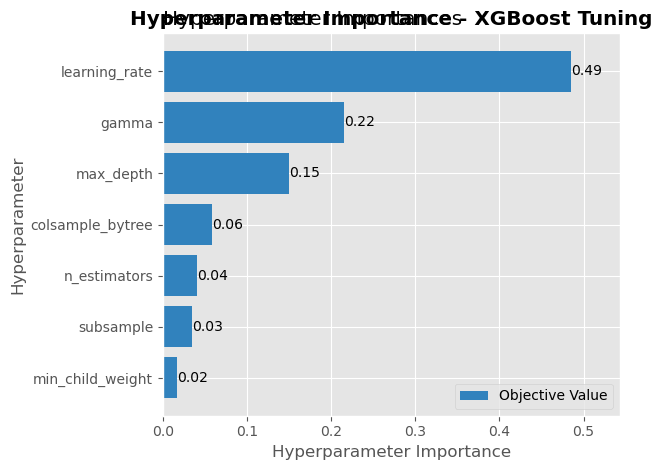

Saved: ../plots/Day11_optuna_param_importance_xgb.png


In [12]:
# ============================================================
# CELL 10: WHICH HYPERPARAMETERS MATTERED MOST? (XGBOOST)
# ============================================================
# This shows which hyperparameters had the BIGGEST influence on
# the AUC score across all trials - helps you understand what to
# focus tuning effort on next time.

fig = plt.figure(figsize=(9, 5))
ax = plot_param_importances(study_xgb)
ax.set_title('Hyperparameter Importance - XGBoost Tuning', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day11_optuna_param_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../plots/Day11_optuna_param_importance_xgb.png')


In [13]:
# ============================================================
# CELL 11: TRAIN FINAL XGBOOST WITH BEST PARAMS AND EVALUATE ON TEST SET
# ============================================================
# Now we retrain on the FULL training set (tune_train + tune_val combined,
# i.e. the original X_train) using the best hyperparameters, then evaluate
# on the untouched X_test for an honest final score.

best_params_xgb = study_xgb.best_params.copy()
best_params_xgb['scale_pos_weight'] = (y_train == 0).sum() / (y_train == 1).sum()
best_params_xgb['eval_metric'] = 'auc'
best_params_xgb['random_state'] = 42
best_params_xgb['use_label_encoder'] = False

churn_model_tuned = xgb.XGBClassifier(**best_params_xgb)
churn_model_tuned.fit(X_train, y_train)

test_pred_proba_tuned = churn_model_tuned.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, test_pred_proba_tuned)

# Precision@Top20% for the tuned model
eval_tuned = pd.DataFrame({'actual': y_test.values, 'pred_proba': test_pred_proba_tuned})
eval_tuned_sorted = eval_tuned.sort_values('pred_proba', ascending=False).reset_index(drop=True)
top20_n = int(len(eval_tuned_sorted) * 0.20)
precision_at_20_tuned = eval_tuned_sorted.head(top20_n)['actual'].mean()

print('FINAL COMPARISON: BASELINE vs TUNED (XGBoost Churn Model)')
print('=' * 60)
print(f'  Metric                  Baseline      Tuned       Change')
print(f'  AUC-ROC               {churn_metrics_baseline["auc_roc"]:>8.4f}   '
      f'{auc_tuned:>8.4f}   {auc_tuned - churn_metrics_baseline["auc_roc"]:>+8.4f}')
print(f'  Precision@Top20%      {churn_metrics_baseline["precision_at_top20"]:>8.4f}   '
      f'{precision_at_20_tuned:>8.4f}   '
      f'{precision_at_20_tuned - churn_metrics_baseline["precision_at_top20"]:>+8.4f}')
print('=' * 60)


FINAL COMPARISON: BASELINE vs TUNED (XGBoost Churn Model)
  Metric                  Baseline      Tuned       Change
  AUC-ROC                 0.8143     0.8183    +0.0040
  Precision@Top20%        0.8863     0.8957    +0.0095


## PART C: Optuna Hyperparameter Tuning for the Forecasting Model (LSTM)

**Search space we will tune:**

| Hyperparameter | Range | Effect |
|-----------------|-------|--------|
| `hidden_size` | 16-128 | Number of LSTM memory cells |
| `num_layers` | 1-3 | Number of stacked LSTM layers |
| `dropout` | 0.0-0.5 | Regularization strength |
| `learning_rate` | 0.0001-0.01 (log scale) | Optimizer step size |
| `lookback` | 14-45 | Number of past days fed into the model |

**Objective:** minimize MAPE on a held-out validation slice of the time series
(we keep this CHRONOLOGICALLY separate from the final Day 8 test period -
never shuffle time series data!).


In [14]:
# ============================================================
# CELL 12: LOAD TIME SERIES DATA FOR LSTM TUNING
# ============================================================

daily = pd.read_csv('../data/prophet_ready.csv', parse_dates=['ds'])
daily = daily.sort_values('ds').reset_index(drop=True)

values = daily['y'].values.reshape(-1, 1)
scaler_lstm = MinMaxScaler()
values_scaled = scaler_lstm.fit_transform(values)

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def mape_fn(actual, predicted):
    actual = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

print(f'Time series length: {len(daily)} days')
print('Sequences/scaler helper functions and MAPE function ready')


Time series length: 739 days
Sequences/scaler helper functions and MAPE function ready


In [15]:
# ============================================================
# CELL 13: DEFINE THE LSTM ARCHITECTURE (PARAMETERIZED)
# ============================================================

class TunableLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2,
                 dropout=0.2, output_size=1):
        super(TunableLSTM, self).__init__()
        # dropout only applies between LSTM layers, so it's ignored if num_layers=1
        actual_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=actual_dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

print('TunableLSTM architecture defined (hidden_size, num_layers, dropout are tunable)')


TunableLSTM architecture defined (hidden_size, num_layers, dropout are tunable)


In [16]:
# ============================================================
# CELL 14: DEFINE THE OPTUNA OBJECTIVE FUNCTION (LSTM)
# ============================================================
# For each trial, Optuna picks a lookback window, rebuilds sequences,
# splits chronologically into train/validation (80/20, NO shuffling),
# trains a small LSTM, and returns the validation MAPE to MINIMIZE.
#
# NOTE: To keep runtime reasonable, we use fewer epochs (15) during
# the search than we would for a final model. This is a common
# practical trade-off in hyperparameter search.

def lstm_objective(trial):
    lookback      = trial.suggest_int('lookback', 14, 45)
    hidden_size   = trial.suggest_int('hidden_size', 16, 128, step=16)
    num_layers    = trial.suggest_int('num_layers', 1, 3)
    dropout       = trial.suggest_float('dropout', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 0.0001, 0.01, log=True)

    X_seq, y_seq = create_sequences(values_scaled, lookback)

    # Chronological split - never shuffle time series!
    split_idx = int(len(X_seq) * 0.8)
    X_tr, X_val = X_seq[:split_idx], X_seq[split_idx:]
    y_tr, y_val = y_seq[:split_idx], y_seq[split_idx:]

    if len(X_val) < 5:
        return 999.0   # not enough validation data for this lookback, penalize

    X_tr_t = torch.FloatTensor(X_tr)
    y_tr_t = torch.FloatTensor(y_tr)
    X_val_t = torch.FloatTensor(X_val)

    train_ds = TensorDataset(X_tr_t, y_tr_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)

    model = TunableLSTM(hidden_size=hidden_size, num_layers=num_layers, dropout=dropout)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    EPOCHS_SEARCH = 15
    for epoch in range(EPOCHS_SEARCH):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred_scaled = model(X_val_t).numpy()

    val_pred = scaler_lstm.inverse_transform(val_pred_scaled)
    val_actual = scaler_lstm.inverse_transform(y_val)

    score = mape_fn(val_actual, val_pred)
    return score

print('LSTM objective function defined.')
print('Goal: MINIMIZE MAPE on chronological validation slice')


LSTM objective function defined.
Goal: MINIMIZE MAPE on chronological validation slice


In [17]:
# ============================================================
# CELL 15: RUN OPTUNA STUDY FOR LSTM (FORECASTING MODEL)
# ============================================================
# NOTE: This cell trains a small neural network multiple times,
# so it will take longer than the XGBoost search. Reduce N_TRIALS_LSTM
# if you need faster results (e.g. 15-20 trials still gives good results).

N_TRIALS_LSTM = 25

study_lstm = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

print(f'Running {N_TRIALS_LSTM} Optuna trials for LSTM (Forecasting model) ...')
print('This may take a few minutes ...')
study_lstm.optimize(lstm_objective, n_trials=N_TRIALS_LSTM, show_progress_bar=True)

print()
print('Optuna search complete!')
print(f'  Best validation MAPE : {study_lstm.best_value:.2f}%')
print(f'  Best trial number    : {study_lstm.best_trial.number}')
print()
print('Best hyperparameters found:')
for key, val in study_lstm.best_params.items():
    print(f'  {key}: {val}')


Running 25 Optuna trials for LSTM (Forecasting model) ...
This may take a few minutes ...


  0%|          | 0/25 [00:00<?, ?it/s]


Optuna search complete!
  Best validation MAPE : 35.96%
  Best trial number    : 23

Best hyperparameters found:
  lookback: 30
  hidden_size: 128
  num_layers: 2
  dropout: 0.2180499167861401
  learning_rate: 0.0012010038053700386


<Figure size 1000x500 with 0 Axes>

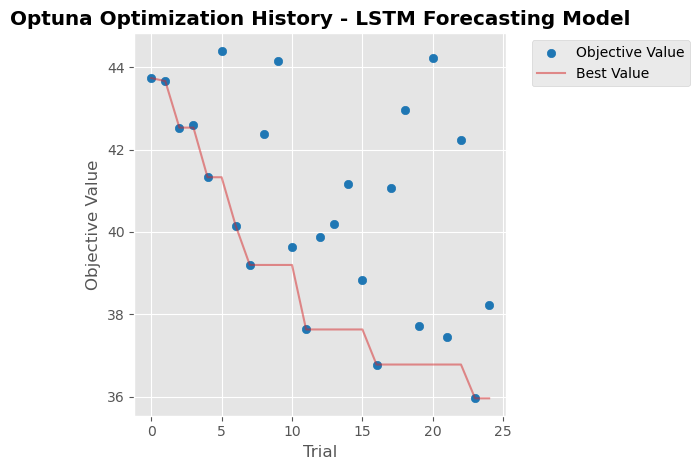

<Figure size 900x500 with 0 Axes>

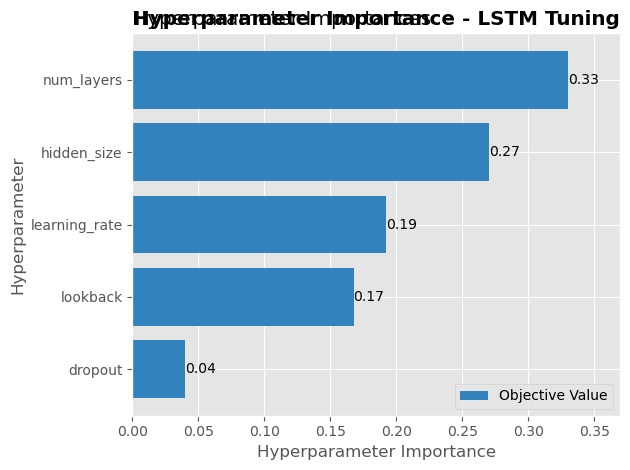

Saved both Optuna LSTM plots to ../plots/


In [23]:
# ============================================================
# CELL 16: VISUALIZE OPTUNA RESULTS FOR LSTM
# ============================================================

fig = plt.figure(figsize=(10, 5))
ax = plot_optimization_history(study_lstm)
ax.set_title('Optuna Optimization History - LSTM Forecasting Model', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day11_optuna_history_lstm.png', dpi=150, bbox_inches='tight')
plt.show()




fig2 = plt.figure(figsize=(9, 5))


ax2 = plot_param_importances(study_lstm)
ax2.set_title('Hyperparameter Importance - LSTM Tuning', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/Day11_optuna_param_importance_lstm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved both Optuna LSTM plots to ../plots/')


In [24]:
# ============================================================
# CELL 17: TRAIN FINAL LSTM WITH BEST PARAMS (MORE EPOCHS)
# ============================================================
# Now that we know the best hyperparameters, train a FINAL model
# with more epochs (50, same as Day 6) for a stronger fit.

best_params_lstm = study_lstm.best_params

best_lookback      = best_params_lstm['lookback']
best_hidden_size   = best_params_lstm['hidden_size']
best_num_layers    = best_params_lstm['num_layers']
best_dropout       = best_params_lstm['dropout']
best_learning_rate = best_params_lstm['learning_rate']

X_seq, y_seq = create_sequences(values_scaled, best_lookback)
split_idx = int(len(X_seq) * 0.8)
X_tr, X_te = X_seq[:split_idx], X_seq[split_idx:]
y_tr, y_te = y_seq[:split_idx], y_seq[split_idx:]

X_tr_t, y_tr_t = torch.FloatTensor(X_tr), torch.FloatTensor(y_tr)
X_te_t = torch.FloatTensor(X_te)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)

lstm_tuned = TunableLSTM(hidden_size=best_hidden_size, num_layers=best_num_layers,
                          dropout=best_dropout)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_tuned.parameters(), lr=best_learning_rate)

EPOCHS_FINAL = 50
for epoch in range(EPOCHS_FINAL):
    lstm_tuned.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = lstm_tuned(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS_FINAL} - Loss: {epoch_loss/len(train_loader):.6f}')

lstm_tuned.eval()
with torch.no_grad():
    test_pred_scaled = lstm_tuned(X_te_t).numpy()

test_pred_lstm_tuned = scaler_lstm.inverse_transform(test_pred_scaled)
test_actual_lstm     = scaler_lstm.inverse_transform(y_te)

mape_lstm_tuned = mape_fn(test_actual_lstm, test_pred_lstm_tuned)

print()
print(f'Final tuned LSTM test MAPE: {mape_lstm_tuned:.2f}%')


Epoch 10/50 - Loss: 0.008680
Epoch 20/50 - Loss: 0.006873
Epoch 30/50 - Loss: 0.004889
Epoch 40/50 - Loss: 0.004329
Epoch 50/50 - Loss: 0.004049

Final tuned LSTM test MAPE: 38.91%


In [25]:
# ============================================================
# CELL 18: COMPARE BASELINE LSTM (DAY 6) VS TUNED LSTM (DAY 11)
# ============================================================

# Load Day 6 baseline MAPE if available, else use the value from Day 7/8 context
try:
    with open('../models/hybrid_config.json', 'r') as f:
        hybrid_config = json.load(f)
    baseline_lstm_mape = hybrid_config.get('lstm_mape', None)
except FileNotFoundError:
    baseline_lstm_mape = None

print('FINAL COMPARISON: BASELINE vs TUNED (LSTM Forecasting Model)')
print('=' * 55)
if baseline_lstm_mape is not None:
    print(f'  Baseline LSTM MAPE (Day 6/8) : {baseline_lstm_mape:.2f}%')
else:
    print('  Baseline LSTM MAPE (Day 6/8) : not found, check ../models/hybrid_config.json')
print(f'  Tuned LSTM MAPE (Day 11)      : {mape_lstm_tuned:.2f}%')
if baseline_lstm_mape is not None:
    improvement = baseline_lstm_mape - mape_lstm_tuned
    print(f'  Improvement                   : {improvement:+.2f} percentage points')
print('=' * 55)
print()
print('Best LSTM hyperparameters found by Optuna:')
for key, val in best_params_lstm.items():
    print(f'  {key}: {val}')


FINAL COMPARISON: BASELINE vs TUNED (LSTM Forecasting Model)
  Baseline LSTM MAPE (Day 6/8) : 38.08%
  Tuned LSTM MAPE (Day 11)      : 38.91%
  Improvement                   : -0.83 percentage points

Best LSTM hyperparameters found by Optuna:
  lookback: 30
  hidden_size: 128
  num_layers: 2
  dropout: 0.2180499167861401
  learning_rate: 0.0012010038053700386


## Save Tuned Models and Final Comparison Report

In [26]:
# ============================================================
# CELL 19: SAVE TUNED MODELS AND HYPERPARAMETERS
# ============================================================

# Save tuned XGBoost (churn) model
with open('../models/churn_xgboost_tuned.pkl', 'wb') as f:
    pickle.dump(churn_model_tuned, f)

# Save tuned LSTM (forecasting) model
torch.save(lstm_tuned.state_dict(), '../models/lstm_tuned.pth')

# Save all tuning results and best hyperparameters
tuning_results = {
    'churn_model': {
        'baseline_auc': churn_metrics_baseline['auc_roc'],
        'tuned_auc': float(auc_tuned),
        'baseline_precision_at_20': churn_metrics_baseline['precision_at_top20'],
        'tuned_precision_at_20': float(precision_at_20_tuned),
        'best_params': study_xgb.best_params,
        'n_trials': N_TRIALS_XGB
    },
    'forecasting_model': {
        'baseline_mape': baseline_lstm_mape,
        'tuned_mape': float(mape_lstm_tuned),
        'best_params': best_params_lstm,
        'n_trials': N_TRIALS_LSTM
    },
    'permutation_importance_top5': perm_importance.head(5).to_dict(orient='records')
}

with open('../models/day11_tuning_results.json', 'w') as f:
    json.dump(tuning_results, f, indent=2)

# Save permutation importance table
perm_importance.to_csv('../data/permutation_importance.csv', index=False)

print('Saved:')
print('  ../models/churn_xgboost_tuned.pkl    <- tuned XGBoost churn model')
print('  ../models/lstm_tuned.pth             <- tuned LSTM forecasting model')
print('  ../models/day11_tuning_results.json  <- all tuning results and best params')
print('  ../data/permutation_importance.csv   <- permutation importance table')


Saved:
  ../models/churn_xgboost_tuned.pkl    <- tuned XGBoost churn model
  ../models/lstm_tuned.pth             <- tuned LSTM forecasting model
  ../models/day11_tuning_results.json  <- all tuning results and best params
  ../data/permutation_importance.csv   <- permutation importance table


In [27]:
# ============================================================
# CELL 20: DAY 11 SUMMARY
# ============================================================

print('=' * 60)
print('  DAY 11 COMPLETE - FEATURE IMPORTANCE AND OPTUNA TUNING')
print('=' * 60)
print()
print('  PART A: FEATURE IMPORTANCE')
print(f'    Top feature (built-in)     : {builtin_importance.index[0]}')
print(f'    Top feature (permutation)  : {perm_importance.iloc[0]["Feature"]}')
print(f'    Rank correlation           : {corr:.3f}')
print()
print('  PART B: CHURN MODEL TUNING (XGBoost, Optuna)')
print(f'    Trials run                 : {N_TRIALS_XGB}')
print(f'    Baseline AUC-ROC           : {churn_metrics_baseline["auc_roc"]:.4f}')
print(f'    Tuned AUC-ROC              : {auc_tuned:.4f}')
print(f'    Baseline Precision@Top20%  : {churn_metrics_baseline["precision_at_top20"]:.4f}')
print(f'    Tuned Precision@Top20%     : {precision_at_20_tuned:.4f}')
print()
print('  PART C: FORECASTING MODEL TUNING (LSTM, Optuna)')
print(f'    Trials run                 : {N_TRIALS_LSTM}')
if baseline_lstm_mape is not None:
    print(f'    Baseline MAPE              : {baseline_lstm_mape:.2f}%')
print(f'    Tuned MAPE                 : {mape_lstm_tuned:.2f}%')
print()
print('  KEY TAKEAWAYS:')
print('  - Optuna uses TPE (Tree-structured Parzen Estimator) to intelligently')
print('    search hyperparameter space, far more efficient than grid search.')
print('  - Permutation importance confirms (or challenges) XGBoost built-in')
print('    importance using a model-agnostic, test-set-based method.')
print('  - All tuning used a separate validation split - the final test set')
print('    was never touched during the search, giving an honest evaluation.')
print()
print('  PLOTS SAVED:')
for p in ['Day11_importance_comparison.png','Day11_optuna_history_xgb.png',
          'Day11_optuna_param_importance_xgb.png','Day11_optuna_history_lstm.png',
          'Day11_optuna_param_importance_lstm.png']:
    print(f'    ../plots/{p}')
print()
print('  Ready for Day 12: Drift Detection Setup using Evidently AI')
print('=' * 60)


  DAY 11 COMPLETE - FEATURE IMPORTANCE AND OPTUNA TUNING

  PART A: FEATURE IMPORTANCE
    Top feature (built-in)     : AvgDaysBetweenOrders
    Top feature (permutation)  : AvgDaysBetweenOrders
    Rank correlation           : 0.758

  PART B: CHURN MODEL TUNING (XGBoost, Optuna)
    Trials run                 : 50
    Baseline AUC-ROC           : 0.8143
    Tuned AUC-ROC              : 0.8183
    Baseline Precision@Top20%  : 0.8863
    Tuned Precision@Top20%     : 0.8957

  PART C: FORECASTING MODEL TUNING (LSTM, Optuna)
    Trials run                 : 25
    Baseline MAPE              : 38.08%
    Tuned MAPE                 : 38.91%

  KEY TAKEAWAYS:
  - Optuna uses TPE (Tree-structured Parzen Estimator) to intelligently
    search hyperparameter space, far more efficient than grid search.
  - Permutation importance confirms (or challenges) XGBoost built-in
    importance using a model-agnostic, test-set-based method.
  - All tuning used a separate validation split - the final test